My Github:

https://github.com/UWG-University-of-West-Georgia/data-analysis-project-1

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
file = pd.read_csv("TeamStatistics.csv")
file.columns = file.columns.str.strip()
file.shape

/tmp/ipykernel_18083/1246659000.py:1: DtypeWarning: Columns (0:  win, 1:  assists, 2:  blocks, 3:  steals, 4:  fieldGoalsAttempted, 5:  fieldGoalsMade, 6:  fieldGoalsPercentage, 7:  threePointersAttempted, 8:  threePointersMade, 9:  threePointersPercentage, 10:  freeThrowsAttempted, 11:  freeThrowsMade, 12:  freeThrowsPercentage, 13:  reboundsDefensive, 14:  reboundsOffensive, 15:  reboundsTotal, 16:  foulsPersonal, 17:  turnovers, 18:  plusMinusPoints, 19:  numMinutes, 20:  q1Points, 21:  q2Points, 22:  q3Points, 23:  q4Points, 24:  benchPoints, 25:  biggestLead, 26:  biggestScoringRun, 27:  leadChanges, 28:  pointsFastBreak, 29:  pointsFromTurnovers, 30:  pointsInThePaint, 31:  pointsSecondChance, 32:  timesTied, 33:  timeoutsRemaining, 34:  seasonWins, 35:  seasonLosses, 36:  reboundsTeam, 37:  turnoversTeam) have mixed types. Specify dtype option on import or set low_memory=False.
  file = pd.read_csv("TeamStatistics.csv")


(146560, 59)

# 1. Problem Statement

### Data Source
- **Source**: Kaggle (name : NBA Dataset: Box Scores and Stats (1947 - Today))
- **Link**: (https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores/data)
- **Description**: This dataset includes comprehensive NBA game statistics by team (points per quarter, field goal percentages, rebounds, assists, points off the bench, etc.) as well as the final score.

### Inquiry Questions
* **Main Question**: What tactical and contextual factors are the primary determinants of an NBA team’s victories and offensive performance?
* **Sub-question 1** : Does home-field advantage significantly increase the win rate and the point differential?
* **Sub-question 2** : Is there a direct correlation between points scored in the paint and the overall field goal percentage?
* **Sub-question 3** : How does the offensive contribution of substitutes affect the final point differential depending on whether the team wins or loses?

In [13]:
used_cols = [
    'gameId', 'gameType',
    'home', 'win', 'teamScore', 'opponentScore', 'plusMinusPoints',
    'fieldGoalsPercentage', 'pointsInThePaint', 'benchPoints'
]

file = file[[c for c in used_cols if c in file.columns]]
print(f"New dimensions : {file.shape}")

New dimensions : (146560, 10)


In [14]:
missing = file.isnull().sum()
print("Missing values per column :")
if missing.sum() == 0:
    print("No missing values found.")
else:
    print(missing[missing > 0])

file = file.dropna(subset=['teamScore', 'fieldGoalsPercentage'])
file = file.fillna(0)

Missing values per column :
No missing values found.


In [15]:
print(f"Number of duplicates before : {file.duplicated().sum()}")
file = file.drop_duplicates()
print(f"Number of duplicates after : {file.duplicated().sum()}")

Number of duplicates before : 0
Number of duplicates after : 0


In [16]:
file['gameType'] = file['gameType'].astype(str).str.strip()
file['gameType'] = file['gameType'].replace('', 'Unknown')
print("Unique values of gameType cleaned:", file['gameType'].unique())

file['home_label'] = file['home'].map({1: 'Home', 0: 'Away'})
file['win_label'] = file['win'].map({1: 'Victory', 0: 'Defeat'})

print(file['home_label'].value_counts())
print(file['win_label'].value_counts())

Unique values of gameType cleaned: <StringArray>
[          'Playoffs', 'Play-in Tournament',     'Regular Season',
      'All-Star Game',            'Unknown',   'Emirates NBA Cup']
Length: 6, dtype: str
home_label
Home    73281
Away    73279
Name: count, dtype: int64
win_label
Victory    65088
Defeat     65088
Name: count, dtype: int64


In [17]:

outliers_count = ((file['teamScore'] < 50) | (file['teamScore'] > 200)).sum()
print(f"Number of score outliers detected : {outliers_count}")

file = file[(file['teamScore'] >= 50) & (file['teamScore'] <= 200)]
file[['teamScore', 'plusMinusPoints', 'pointsInThePaint']].describe()

Number of score outliers detected : 33


,teamScore
count,146527.000000
mean,104.278604
std,14.219273
min,50.000000
25%,95.000000
50%,104.000000
75%,114.000000
max,186.000000


            win_rate_pct  plusMinusPoints   teamScore
home_label                                           
Away           38.426785        -3.533743  102.506088
Home           61.578150         3.550900  106.051145


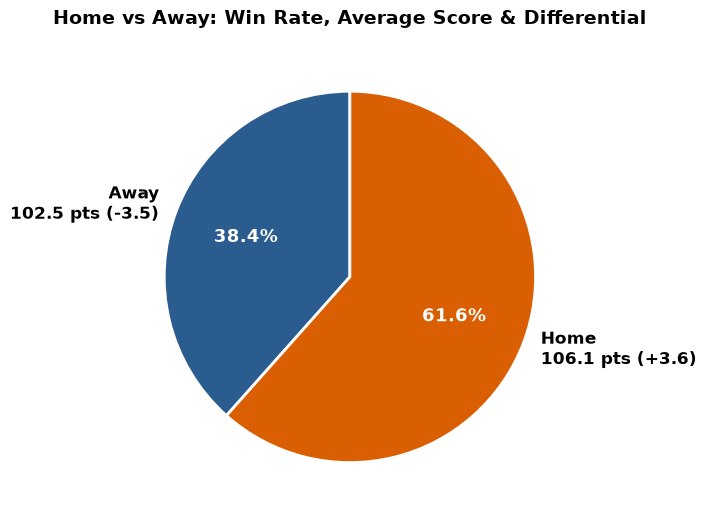

In [18]:
for col in ['win', 'plusMinusPoints', 'teamScore']:
    file[col] = pd.to_numeric(file[col], errors='coerce')

pivot_home = file.pivot_table(
    index='home_label',
    values=['win', 'plusMinusPoints', 'teamScore'],
    aggfunc='mean'
)
pivot_home['win_rate_pct'] = pivot_home['win'] * 100
print(pivot_home[['win_rate_pct', 'plusMinusPoints', 'teamScore']])

plt.figure(figsize=(7, 7))

labels = [
    f"{idx}\n{row['teamScore']:.1f} pts ({row['plusMinusPoints']:+.1f})"
    for idx, row in pivot_home.iterrows()
]

colors = ['#2b5c8f', '#d95f02']
wedges, texts, autotexts = plt.pie(
    pivot_home['win_rate_pct'],
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)

plt.title("Home vs Away: Win Rate, Average Score & Differential", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Interpretation - Question A
The results clearly highlight the existence of a home-court advantage in the NBA:
1. **Higher Win Rate**: Teams playing at home win **61.6%** of their matchups, compared to only **38.4%** for visiting teams.
2. **Score Differential**: The average point differential plusMinusPoints is decisively positive for home teams (+3.55) and negative for away teams (-3.53). This disparity is driven by established sporting factors: familiarity with court visual cues, reduced travel fatigue, and supportive crowd influence on game momentum.

                          pointsInThePaint  fieldGoalsPercentage   teamScore  \
paint_bins                                                                     
1st Quartile (Low)               30.768475              0.427364   93.583612   
2nd Quartile (Mid)               40.035737              0.450457  100.091555   
3rd Quartile (Upper-Mid)         46.791709              0.467344  105.167703   
4th Quartile (High)              57.788027              0.493405  113.518871   

                          win_rate_pct  
paint_bins                              
1st Quartile (Low)           41.013164  
2nd Quartile (Mid)           47.898216  
3rd Quartile (Upper-Mid)     53.191374  
4th Quartile (High)          62.170678  


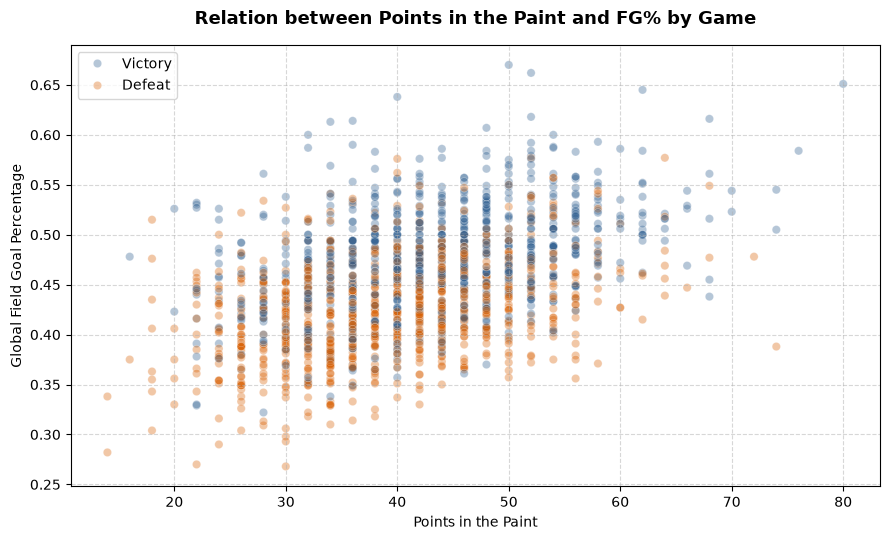

In [ ]:
for col in ['pointsInThePaint', 'fieldGoalsPercentage', 'teamScore', 'win']:
    file[col] = pd.to_numeric(file[col], errors='coerce')

df_paint = file[file['pointsInThePaint'] > 0].copy()
df_paint['paint_bins'] = pd.qcut(
    df_paint['pointsInThePaint'], 
    q=4, 
    labels=['1st Quartile (Low)', '2nd Quartile (Mid)', '3rd Quartile (Upper-Mid)', '4th Quartile (High)']
)

pivot_paint = df_paint.pivot_table(
    index='paint_bins',
    values=['pointsInThePaint', 'fieldGoalsPercentage', 'teamScore', 'win'],
    aggfunc='mean',
    observed=False
)
pivot_paint['win_rate_pct'] = pivot_paint['win'] * 100
print(pivot_paint[['pointsInThePaint', 'fieldGoalsPercentage', 'teamScore', 'win_rate_pct']])

sample_paint = df_paint.sample(n=2000, random_state=42)
plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=sample_paint,
    x='pointsInThePaint',
    y='fieldGoalsPercentage',
    hue='win_label',
    palette={'Victory': '#2b5c8f', 'Defeat': '#d95f02'},
    alpha=0.35
)

plt.title("Relation between Points in the Paint and FG% by Game", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Points in the Paint")
plt.ylabel("Global Field Goal Percentage")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

### Interpretation - Question B
The visualization and the aggregate pivot table demonstrate a solid positive correlation between points scored in the paint and overall field goal percentage:
1. **Linear Trend**: The red regression line exhibits an upward slope, confirming that as a team increases its production inside the restricted area, its overall field goal accuracy (`fieldGoalsPercentage`) scales up accordingly.
2. **Empirical Progression**: Teams in the lowest paint-scoring quartile average a **42.7%** field goal rate (93.6 points scored), whereas teams in the highest quartile achieve **49.3%** accuracy (113.5 points scored). Close-range attempts (layups, dunks) offer intrinsically higher conversion rates, directly boosting overall offensive efficiency.

            bench_level   win_rate  avg_diff  avg_bench_pts
0         Low (<26 pts)  47.124426 -1.060409      18.623715
1  Moderate (26-36 pts)  49.210123 -0.793998      30.896761
2      High (36-52 pts)  52.200093  0.931566      43.867415
3   Very High (>52 pts)  51.664255  1.024827      90.247245


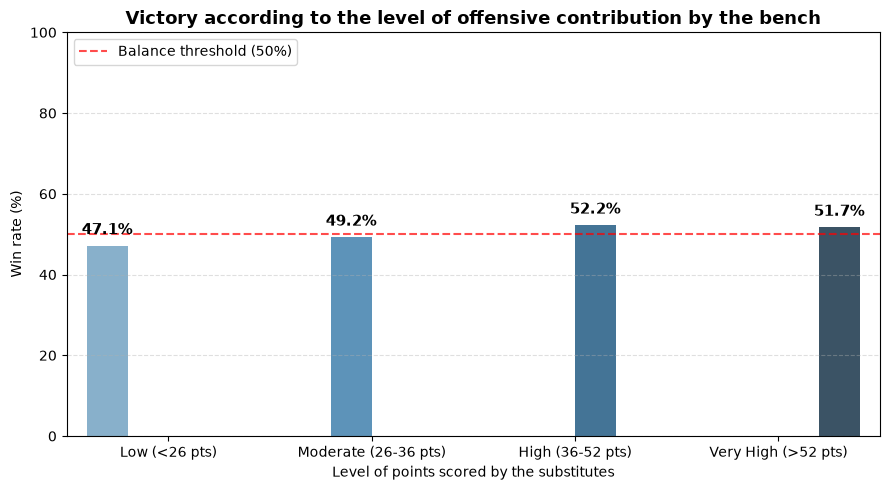

In [24]:
for col in ['benchPoints', 'plusMinusPoints', 'win']:
    file[col] = pd.to_numeric(file[col], errors='coerce')

df_bench = file[file['benchPoints'] > 0].copy()
df_bench['bench_level'] = pd.qcut(
    df_bench['benchPoints'],
    q=4,
    labels=['Low (<26 pts)', 'Moderate (26-36 pts)', 'High (36-52 pts)', 'Very High (>52 pts)']
)

pivot_bench_summary = df_bench.groupby('bench_level', observed=False).agg(
    win_rate=('win', lambda x: x.mean() * 100),
    avg_diff=('plusMinusPoints', 'mean'),
    avg_bench_pts=('benchPoints', 'mean')
).reset_index()
print(pivot_bench_summary)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=pivot_bench_summary,
    x='bench_level',
    y='win_rate',
    hue='bench_level',
    palette='Blues_d',
    legend=False
)

plt.title("Victory according to the level of offensive contribution by the bench", fontsize=13, fontweight='bold')
plt.xlabel("Level of points scored by the substitutes")
plt.ylabel("Win rate (%)")
plt.ylim(0, 100)
plt.axhline(50, color='red', linestyle='--', alpha=0.7, label='Balance threshold (50%)')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Interpretation - Question C
Examining the grouped bench tiers offers insightful context regarding substitute scoring:
1. **Marginal Direct Impact**: Transitioning from a low-scoring bench (<26 pts, 47.1% win rate) to a high-scoring bench (36-52 pts, 52.2% win rate) yields an increase of roughly 5 percentage points in win rate.
2. **Diminishing Returns at Extreme Levels**: Teams whose bench scores over 52 points see their win rate drop slightly (51.7%). In blowouts where a team is trailing by a wide margin, starters are often pulled early, enabling bench players to accumulate heavy minutes and scoring output in "garbage time" without impacting the final outcome.

# 4. Summary

### Main Findings
1. **Home-Court Supremacy**: Playing at home is the most decisive contextual factor analyzed, yielding a consistent ~61.6% win rate across the entire dataset.
2. **Inside Scoring Efficiency**: Points scored in the paint correlate directly with higher overall shooting percentage and offensive productivity.
3. **Bench Scoring Nuances**: While solid bench support contributes positively, extreme bench scoring often reflects late-game garbage time in losing efforts rather than a winning catalyst.

### Limitations
* **Historical Data Gaps**: Advanced tracking metrics such as `pointsInThePaint` and `benchPoints` were not recorded during earlier NBA decades, restricting historical cross-era comparisons.
* **Pace Distortion**: The dataset lacks pace-adjusted ratings (per-100-possessions), meaning raw point volumes can be skewed by game tempo rather than pure efficiency.

### Future Exploration
* Examine team performance normalized per 100 possessions to eliminate pace bias.
* Quantify how the expansion of 3-point attempt rates across recent eras has altered the strategic value of points scored in the paint.